In [2]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print('All libraries imported successfully.')

All libraries imported successfully.


In [3]:
# Cell 2 — Load Phase 1 dataset
df = pd.read_csv('data/processed/seismic_clean.csv')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
print('\nRisk label distribution:')
print(df['risk_label'].value_counts().sort_index())
print('Label key: 0=Safe  1=Watch  2=Danger  3=Evacuate')

Dataset loaded successfully!
Shape: (9329, 11)

Risk label distribution:
risk_label
0    4228
1    4741
2     329
3      31
Name: count, dtype: int64
Label key: 0=Safe  1=Watch  2=Danger  3=Evacuate


In [4]:
# Cell 3 — Define features & target, split 80/20
FEATURES = ['mag','depth','vibration_hz','acceleration_m2s','floor_level','fire_sensor']
TARGET   = 'risk_label'

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set : {len(X_train)} rows')
print(f'Testing set  : {len(X_test)} rows')

Training set : 7463 rows
Testing set  : 1866 rows


In [5]:
# Cell 4 — Train Random Forest (100 trees)
print('Training Random Forest model...')
model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred   = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'\nModel accuracy: {accuracy * 100:.2f}%')
print('\nDetailed classification report:')
print(classification_report(
    y_test, y_pred,
    target_names=['Safe','Watch','Danger','Evacuate']
))

Training Random Forest model...

Model accuracy: 99.95%

Detailed classification report:
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00       846
       Watch       1.00      1.00      1.00       948
      Danger       0.99      1.00      0.99        66
    Evacuate       1.00      0.83      0.91         6

    accuracy                           1.00      1866
   macro avg       1.00      0.96      0.98      1866
weighted avg       1.00      1.00      1.00      1866



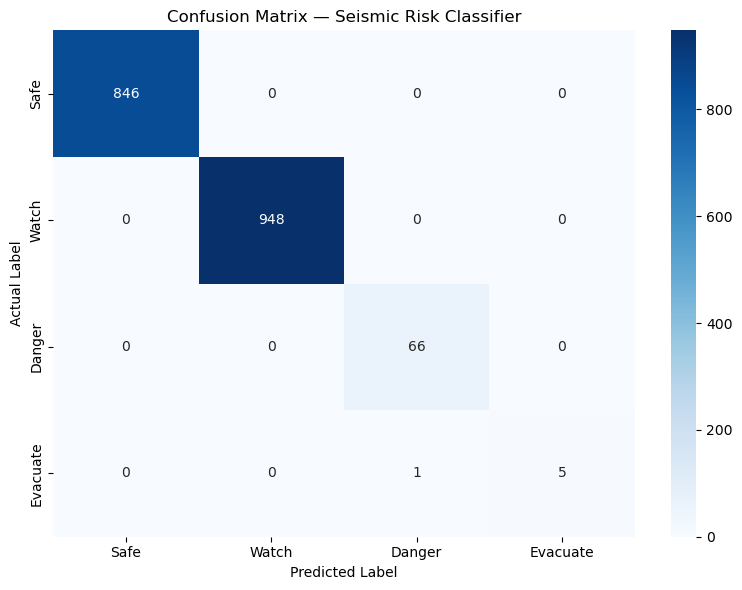

Confusion matrix saved.


In [6]:
# Cell 5 — Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Safe','Watch','Danger','Evacuate'],
    yticklabels=['Safe','Watch','Danger','Evacuate']
)
plt.title('Confusion Matrix — Seismic Risk Classifier')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('data/processed/confusion_matrix.png', dpi=150)
plt.show()
print('Confusion matrix saved.')

In [7]:
# Cell 6 — Real-world validation: Al Haouz earthquake (Sept 8, 2023, M6.8)
al_haouz = pd.DataFrame([{
    'mag':              0.85,
    'depth':            0.03,
    'vibration_hz':     0.92,
    'acceleration_m2s': 0.88,
    'floor_level':      0.5,
    'fire_sensor':      0.75
}])

LABELS = {0:'SAFE', 1:'WATCH', 2:'DANGER', 3:'EVACUATE'}
pred   = model.predict(al_haouz)[0]

print('=== AL HAOUZ EARTHQUAKE VALIDATION ===')
print('Magnitude : 6.8')
print('Location  : Al Haouz, Morocco')
print('Date      : September 8, 2023')
print('Reality   : 3000+ deaths, mass evacuation required')
print(f'\nModel prediction: >>> {LABELS[pred]} <<<')
print('\nResult:', 'CORRECT ✓' if pred == 3 else 'INCORRECT ✗')

=== AL HAOUZ EARTHQUAKE VALIDATION ===
Magnitude : 6.8
Location  : Al Haouz, Morocco
Date      : September 8, 2023
Reality   : 3000+ deaths, mass evacuation required

Model prediction: >>> EVACUATE <<<

Result: CORRECT ✓


In [8]:
# Cell 7 — Save the trained model
joblib.dump(model, 'data/processed/seismic_model.pkl')
print('Model saved to data/processed/seismic_model.pkl')

# Quick reload check
m2 = joblib.load('data/processed/seismic_model.pkl')
print('Model type     :', type(m2))
print('Number of trees:', m2.n_estimators)
print('Features used  :', m2.feature_names_in_.tolist())
print('Risk classes   :', m2.classes_.tolist())
print('\n=== PHASE 2 COMPLETE ===')

Model saved to data/processed/seismic_model.pkl
Model type     : <class 'sklearn.ensemble._forest.RandomForestClassifier'>
Number of trees: 100
Features used  : ['mag', 'depth', 'vibration_hz', 'acceleration_m2s', 'floor_level', 'fire_sensor']
Risk classes   : [0, 1, 2, 3]

=== PHASE 2 COMPLETE ===
